# 1. Classify locations

In [ ]:
import os
os.environ["CUDA_VISIBLE_DEVICES"] = "0,2,3,4,5,6,7"  # Exclude GPU 1 (in use)

import json
from pathlib import Path

import pandas as pd
import torch
print(f"CUDA available? {torch.cuda.is_available()}")
if torch.cuda.is_available():
    for i in range(torch.cuda.device_count()):
        print(f"  GPU {i}: {torch.cuda.get_device_name(i)}")

In [ ]:
from vllm import LLM, SamplingParams
from transformers import AutoProcessor

MODEL = "google/gemma-4-31B-it"

processor = AutoProcessor.from_pretrained(MODEL)
llm = LLM(
    model=MODEL,
    tensor_parallel_size=2,
    max_model_len=8192,
    gpu_memory_utilization=0.90,
    trust_remote_code=True,
)

print(f"Model loaded: {MODEL}")

INFO 05-06 14:28:52 [utils.py:240] non-default args: {'trust_remote_code': True, 'max_model_len': 8192, 'tensor_parallel_size': 2, 'gpu_memory_utilization': 0.9, 'disable_log_stats': True, 'model': 'google/gemma-4-31B-it'}
INFO 05-06 14:29:47 [nixl_utils.py:20] Setting UCX_RCACHE_MAX_UNRELEASED to '1024' to avoid a rare memory leak in UCX when using NIXL.
WARNING 05-06 14:29:47 [nixl_utils.py:34] NIXL is not available
WARNING 05-06 14:29:47 [nixl_utils.py:44] NIXL agent config is not available
INFO 05-06 14:29:47 [model.py:563] Resolved architecture: Gemma4ForConditionalGeneration
INFO 05-06 14:29:47 [model.py:1692] Using max model len 8192
INFO 05-06 14:29:47 [scheduler.py:239] Chunked prefill is enabled with max_num_batched_tokens=16384.
INFO 05-06 14:29:47 [config.py:101] Gemma4 model has heterogeneous head dimensions (head_dim=256, global_head_dim=512). Forcing TRITON_ATTN backend to prevent mixed-backend numerical divergence.
INFO 05-06 14:29:47 [vllm.py:844] Asynchronous scheduli

In [ ]:
SYSTEM_PROMPT = """You are an expert at classifying academic geography papers by the geographic location of their study area.

Given a paper's title and abstract, choose **exactly one** of the following labels:

- USA
- Other North America
- Europe
- Asia
- South America
- Africa
- Australia
- multiple regions
- unclear or conceptual

Guidelines:
- "USA" is reserved for studies focused on the United States. Use "Other North America" for Canada, Mexico, Central America, or the Caribbean.
- Russia and the post-Soviet states — including Siberia, the Caucasus, and the Caspian Sea region — are classified as **Europe** in this taxonomy, even though parts are geographically Asian.
- For papers covering several countries within one continent, use that continent's label.
- For transboundary studies within a continent (e.g., a USA–Mexico border study), pick the primary study area.
- Use "multiple regions" only for cross-continental or global comparative studies (e.g., a paper comparing the USA, Europe, and Asia).
- Use "unclear or conceptual" for theoretical, methodological, or review papers with no specific study area, or when the location cannot be determined from the title and abstract.
- Base your decision only on what is stated in the title and abstract — do not infer locations not mentioned.

Examples:

Input:
Fire is a fundamental tool within a broad spectrum of vegetation-management strategies, from swidden agriculture to plantation forestry. Through the seemingly pyromanic activity of incendiarism, fire assumes additional significance in the human-environment relationship. Case studies from England, Algeria, and the southern United States serve to illustrate the circumstance of fire as an indication of agrarian discontent and a weapon of peasant resistance. Other documented cases of incendiarism reveal that use of fire in the landscape has expanded from a constructive ecosystem-manipulation technique to a destructive form of protest undertaken by the oppressed or disempowered.
Output:
{"location": "multiple regions"}

Input:
This article examines the unintended outcomes of a neoliberal program designed to privatize Mexico's communal lands. Although postrevolutionary agrarian law excluded women from official landholding and leadership positions, steps toward land privatization inadvertently increased women's access to land, government resources, and political power. Using ethnographic and survey data collected in a Veracruz ejido, I demonstrate how Mexico's agrarian counterreforms triggered novel subjectivities and practices.
Output:
{"location": "Other North America"}

Input:
The Colorado River delta is a sedimentary alluvial formation that embodies the Lower Colorado River transboundary aquifer. The Mexicali Valley overlies the Mexican part of the aquifer, and the Imperial Valley the aquifer's portion north of the Mexico-U.S. border. This article presents a methodology applying remote sensing, geographic information analysis, and hydrologic analysis to calculate the annual water deficit in the Mexicali Valley. The work evaluates the valley's annual water deficit in reference to current agricultural and socioeconomic trends observed in the study region.
Output:
{"location": "Other North America"}

Input:
This paper examines migration in Russia during the period that preceded the breakup of the former Soviet Union and during the current transition period. The case study focuses on Yaroslavl Oblast and uses regional-level statistics to identify shifting patterns of inter-regional flows.
Output:
{"location": "Europe"}

Input:
This focus section aims to identify, conceptualize, and understand the emerging geographies of rural crime, in particular those of globalized rural crime, and evaluate their impact on different rural places. Contributions to this focus section span case studies from the United States, England, France, and Brazil to map the global countryside.
Output:
{"location": "multiple regions"}

Respond with a JSON object of the form:
{"location": "<label>"}

Use the exact label strings listed above. Do not include any other text.
"""

print("System prompt ready.")

In [ ]:
CSV_PATH = "/gpfs1/home/j/s/jstonge1/rural-geog-classif/extract/input/Full Dataset Rur Geog WoS 1986-2025 4-28-2026.csv"

df = pd.read_csv(CSV_PATH, usecols=["Article Title", "Abstract", "DOI", "Pub Year", "Authors"])
df = df.rename(columns={
    "Article Title": "title",
    "Abstract": "abstract",
    "DOI": "doi",
    "Pub Year": "year",
    "Authors": "authors",
})

before = len(df)
df = df.dropna(subset=["title", "abstract"])
df = df[df["abstract"].str.strip().astype(bool)]
print(f"Loaded {len(df)} papers with title+abstract (dropped {before - len(df)} missing)")

df.head(3)[["doi", "year", "authors", "title"]]

In [ ]:
from dotenv import load_dotenv
from label_studio_sdk import LabelStudio
import httpx

load_dotenv()

ls_client = LabelStudio(
    base_url=os.getenv("LABEL_STUDIO_URL"),
    api_key=os.getenv("LABEL_STUDIO_API_KEY"),
    httpx_client=httpx.Client(verify=False),
)

PROJECT_ID = 110  # clean re-uploaded project, ground truth in annotations (union of both annotators)

tasks = list(ls_client.tasks.list(project=PROJECT_ID))
print(f"Found {len(tasks)} tasks in project {PROJECT_ID}")

rows = []
for t in tasks:
    if not t.annotations:
        continue
    location_choices = []
    for r in t.annotations[0]["result"]:
        if r.get("from_name") == "Location":
            location_choices = r["value"]["choices"]
            break
    if location_choices:
        rows.append({
            "task_id": t.id,
            "doi": t.data.get("DOI"),
            "locations_gt": location_choices,
        })

gt = pd.DataFrame(rows)
print(f"Pulled {len(gt)} tasks with a Location annotation")
print(gt["locations_gt"].explode().value_counts())

In [20]:
def classify_paper(title, abstract):
    """Classify a paper's study location(s) from its title and abstract."""
    messages = [
        {"role": "system", "content": SYSTEM_PROMPT},
        {"role": "user", "content": f"Title: {title}\n\nAbstract: {abstract}"},
    ]
    prompt = processor.apply_chat_template(
        messages, tokenize=False, add_generation_prompt=True
    )
    outputs = llm.generate(
        [{"prompt": prompt}],
        sampling_params=SamplingParams(temperature=0.0, max_tokens=128),
    )
    return outputs[0].outputs[0].text.strip()

print("classify_paper() ready.")

classify_paper() ready.


In [ ]:
import re

test = gt.merge(df, on="doi", how="inner")
test = test[test["locations_gt"].map(len) == 1].copy()
print(f"Test set: {len(test)} papers (single-label annotations only)")

prompts = [
    processor.apply_chat_template(
        [{"role": "system", "content": SYSTEM_PROMPT},
         {"role": "user", "content": f"Title: {t}\n\nAbstract: {a}"}],
        tokenize=False, add_generation_prompt=True,
    )
    for t, a in zip(test["title"], test["abstract"])
]

outputs = llm.generate(
    [{"prompt": p} for p in prompts],
    sampling_params=SamplingParams(temperature=0.0, max_tokens=64),
)

def parse_location(text):
    m = re.search(r"\{.*\}", text.strip(), re.DOTALL)
    return [json.loads(m.group())["location"]]

test["locations_pred"] = [parse_location(o.outputs[0].text) for o in outputs]
test[["doi", "locations_gt", "locations_pred"]].head()

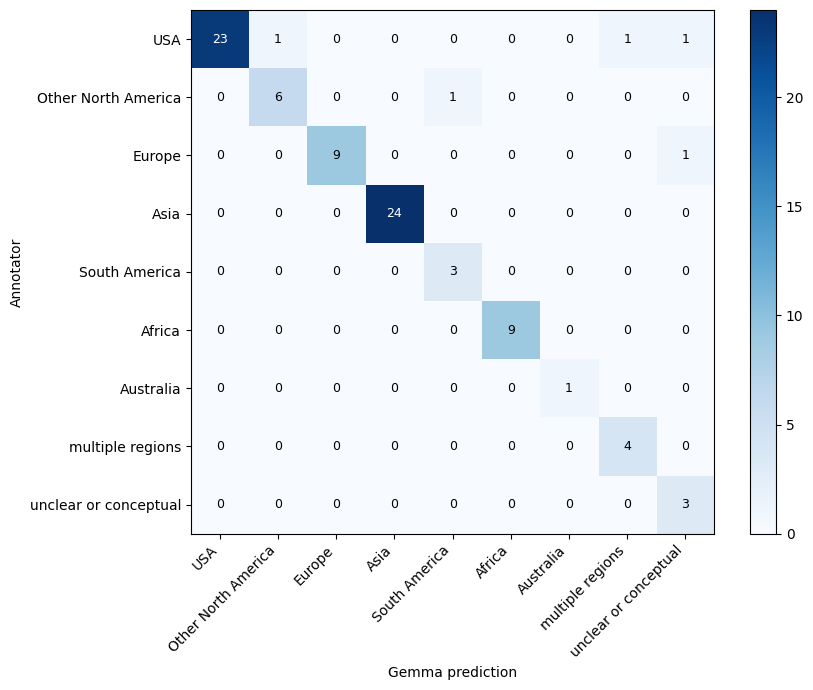


Rows = annotator (ground truth), Cols = Gemma prediction

                       USA  Other North America  Europe  Asia  South America  Africa  Australia  multiple regions  unclear or conceptual
USA                     23                    1       0     0              0       0          0                 1                      1
Other North America      0                    6       0     0              1       0          0                 0                      0
Europe                   0                    0       9     0              0       0          0                 0                      1
Asia                     0                    0       0    24              0       0          0                 0                      0
South America            0                    0       0     0              3       0          0                 0                      0
Africa                   0                    0       0     0              0       9          0                 0      

In [58]:
import numpy as np
import matplotlib.pyplot as plt

LABELS = [
    "USA", "Other North America", "Europe", "Asia", "South America",
    "Africa", "Australia", "multiple regions", "unclear or conceptual",
]

M = np.zeros((len(LABELS), len(LABELS)), dtype=int)
for gt_labels, pred_labels in zip(test["locations_gt"], test["locations_pred"]):
    for g in gt_labels:
        for p in pred_labels:
            if g in LABELS and p in LABELS:
                M[LABELS.index(g), LABELS.index(p)] += 1

fig, ax = plt.subplots(figsize=(9, 7))
im = ax.imshow(M, cmap="Blues")
ax.set_xticks(range(len(LABELS))); ax.set_xticklabels(LABELS, rotation=45, ha="right")
ax.set_yticks(range(len(LABELS))); ax.set_yticklabels(LABELS)
ax.set_xlabel("Gemma prediction"); ax.set_ylabel("Annotator")
for i in range(len(LABELS)):
    for j in range(len(LABELS)):
        c = "white" if M[i, j] > M.max() / 2 else "black"
        ax.text(j, i, M[i, j], ha="center", va="center", color=c, fontsize=9)
fig.colorbar(im); fig.tight_layout()
plt.show()

print("\nRows = annotator (ground truth), Cols = Gemma prediction\n")
with pd.option_context("display.max_columns", None, "display.width", 200):
    print(pd.DataFrame(M, index=LABELS, columns=LABELS).to_string())

exact = sum(set(g) == set(p) for g, p in zip(test["locations_gt"], test["locations_pred"]))
print(f"\nExact-match (label set equality): {exact}/{len(test)} = {exact/len(test):.1%}")

In [62]:
mismatches = test[
    test.apply(lambda r: set(r["locations_gt"]) != set(r["locations_pred"]), axis=1)
].copy()
print(f"Mismatches: {len(mismatches)}/{len(test)}\n")

for _, r in mismatches.head(10).iterrows():
    print(f"GT={r['locations_gt']}  PRED={r['locations_pred']}")
    print(f"  TITLE: {r['title']}")
    print(f"  ABSTR: {r['abstract'][:300]}...")
    print()

Mismatches: 5/87

GT=['Other North America']  PRED=['South America']
  TITLE: GEOGRAPHICAL DIMENSIONS OF THE SHINING PATH INSURGENCY IN PERU
  ABSTR: The Shining Path insurgency began in Peru in 1980. The strategy emphasized rural revolution, establishment of liberated zones, and encirclement of cities. The counterinsurgent campaign in 1983 prevented the creation of a permanent territorial base in the departments of Ayacucho and Apurimac but led ...

GT=['Europe']  PRED=['unclear or conceptual']
  TITLE: Chasing Moving Targets in Rural Spaces: Local Policing and Drug-Related Interventions
  ABSTR: Globalization in rural areas is commonly described in terms of both challenges and opportunities. Opportunities include increased communication and reduced distance. These factors, however, are also favorable for illicit activities such as increased opportunities for marketing drugs on the Internet ...

GT=['USA']  PRED=['multiple regions']
  TITLE: The Making of White Water Citizens in Austr

In [56]:
all_tasks = list(ls_client.tasks.list(project=PROJECT_ID))
to_classify = [
    (t.id, t.data.get("Article Title"), t.data.get("text"))
    for t in all_tasks
    if t.data.get("Article Title") and t.data.get("text")
]
print(f"Classifying {len(to_classify)} / {len(all_tasks)} tasks (skipping any missing title or text)")

prompts = [
    processor.apply_chat_template(
        [{"role": "system", "content": SYSTEM_PROMPT},
         {"role": "user", "content": f"Title: {title}\n\nAbstract: {abstract}"}],
        tokenize=False, add_generation_prompt=True,
    )
    for _, title, abstract in to_classify
]

outputs = llm.generate(
    [{"prompt": p} for p in prompts],
    sampling_params=SamplingParams(temperature=0.0, max_tokens=64),
)

preds = []
for (task_id, _, _), out in zip(to_classify, outputs):
    label = parse_location(out.outputs[0].text)[0]
    preds.append({
        "task": task_id,
        "result": [{
            "from_name": "Location",
            "to_name": "text",
            "type": "choices",
            "value": {"choices": [label]},
        }],
        "model_version": "gemma-4-31B-it-loc-v1",
    })


Classifying 360 / 360 tasks (skipping any missing title or text)


Rendering prompts:   0%|          | 0/360 [00:00<?, ?it/s]

Processed prompts:   0%|                            | 0/360 [00:00<?, ?it/s, est. speed input: 0.00 toks/s, ou…

/tmp/ipykernel_988226/4058198329.py:50: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


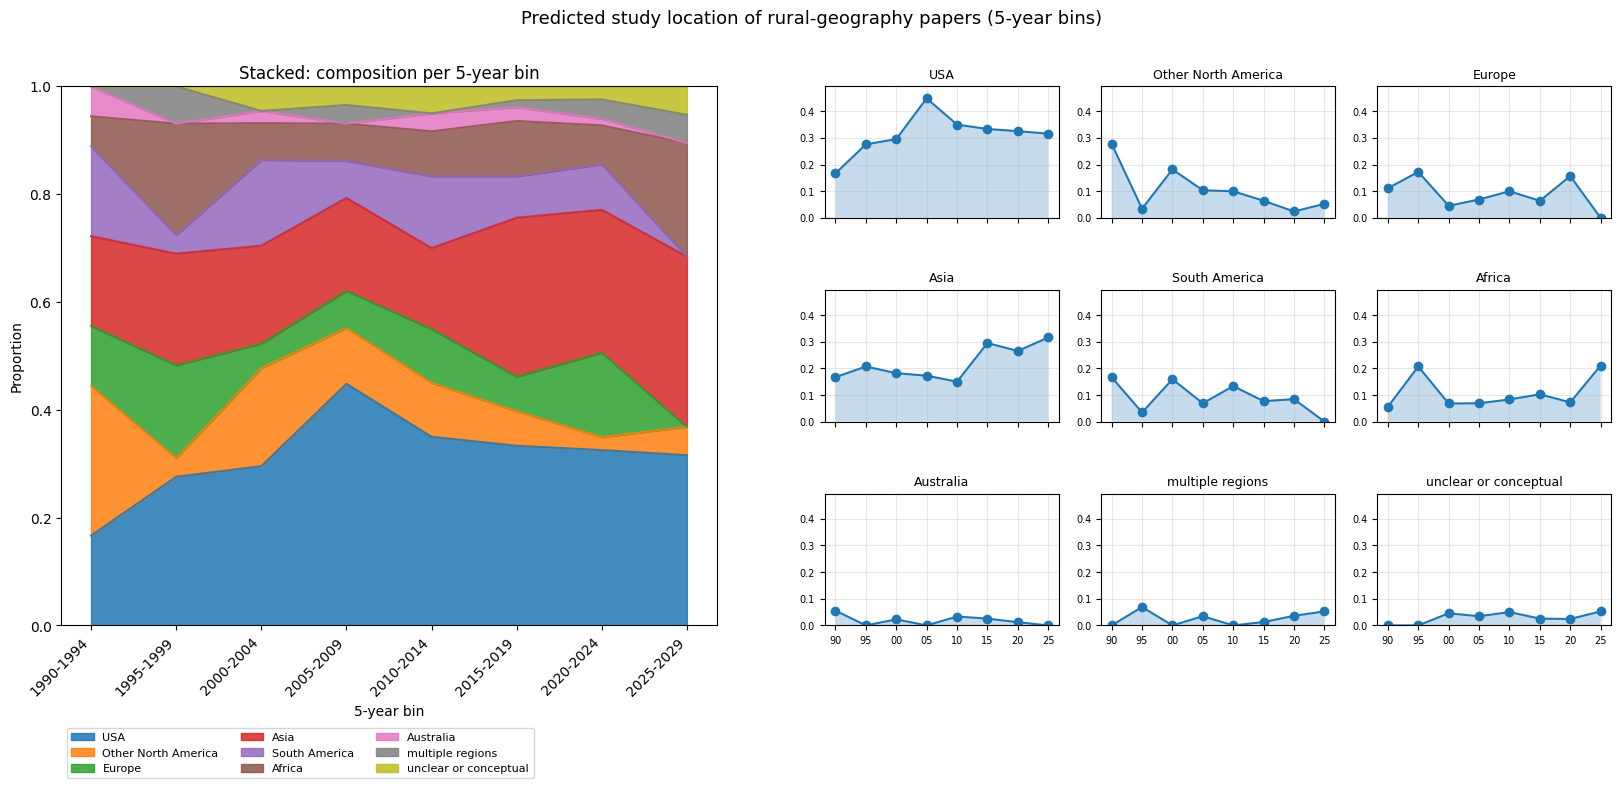


Papers per 5-year bin:
bin
1990    18
1995    29
2000    44
2005    29
2010    60
2015    78
2020    83
2025    19


In [61]:
task_year = {t.id: t.data.get("Pub Year") for t in all_tasks}

results_df = pd.DataFrame([
    {"year": task_year[p["task"]],
     "label": p["result"][0]["value"]["choices"][0]}
    for p in preds
])
results_df = results_df.dropna(subset=["year"])
results_df["year"] = results_df["year"].astype(int)
results_df["bin"] = (results_df["year"] // 5) * 5

counts = results_df.groupby(["bin", "label"]).size().unstack(fill_value=0)
counts = counts.reindex(columns=[l for l in LABELS if l in counts.columns])
props = counts.div(counts.sum(axis=1), axis=0)

fig = plt.figure(figsize=(20, 7))
gs = fig.add_gridspec(1, 2, width_ratios=[1, 1.2], wspace=0.15)

# Left: stacked area
ax_area = fig.add_subplot(gs[0])
props.plot(kind="area", stacked=True, ax=ax_area, alpha=0.85)
ax_area.set_title("Stacked: composition per 5-year bin")
ax_area.set_xlabel("5-year bin")
ax_area.set_ylabel("Proportion")
ax_area.set_xticks(props.index)
ax_area.set_xticklabels([f"{b}-{b+4}" for b in props.index], rotation=45, ha="right")
ax_area.set_ylim(0, 1)
ax_area.legend(loc="upper left", bbox_to_anchor=(0, -0.18), ncol=3, fontsize=8)

# Right: 3x3 small multiples (shared y-axis for comparability)
gs_right = gs[1].subgridspec(3, 3, hspace=0.55, wspace=0.18)
y_max = props.values.max() * 1.1
for idx, label in enumerate(LABELS):
    r, c = divmod(idx, 3)
    ax = fig.add_subplot(gs_right[r, c])
    series = props[label] if label in props.columns else pd.Series(0.0, index=props.index)
    ax.plot(series.index, series.values, marker="o", linewidth=1.5)
    ax.fill_between(series.index, 0, series.values, alpha=0.25)
    ax.set_title(label, fontsize=9)
    ax.set_ylim(0, y_max)
    ax.set_xticks(props.index)
    if r == 2:
        ax.set_xticklabels([str(b)[2:] for b in props.index], fontsize=7)
    else:
        ax.set_xticklabels([])
    ax.tick_params(axis="y", labelsize=7)
    ax.grid(alpha=0.3)

fig.suptitle("Predicted study location of rural-geography papers (5-year bins)", fontsize=13, y=0.99)
plt.tight_layout()
plt.show()

print("\nPapers per 5-year bin:")
print(counts.sum(axis=1).to_string())

In [57]:
print(f"Built {len(preds)} predictions, pushing to project {PROJECT_ID}...")
resp = ls_client.projects.import_predictions(id=PROJECT_ID, request=preds)
print(f"Response: {resp}")

Built 360 predictions, pushing to project 110...
Response: created=360


# 2. Classify topics